# Werkspoorbrug (Amsterdam-Rhine Canal)

## Working file



## Importing Required Packages

Below, the required packages are imported. To run this notebook successfully, your environment must include the required dependencies. The virtual environment provided in MUDE, called **`mude-base`**, is sufficient for this purpose.

In addition, several plotting settings are defined, and the local optimisation code is imported. It is important that the provided zip file is extracted in its entirety, as the structure of the directory is required for the imports to work correctly.

The local module `genetic_algorithm_pfm` is imported using a **relative import**, which depends on the directory structure of the project. When the notebook is executed within the provided directory structure, this will work as intended. However, running the notebook outside of this directory will result in the following error: `ModuleNotFoundError: No module named 'genetic_algorithm_pfm'`

In [114]:
# Import libraries
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import pchip_interpolate
from scipy.optimize import minimize 

# Define default plotting parameters
plt.rcParams['font.size'] = '10'  
plt.rcParams['savefig.dpi'] = 300  

# Import local module for genetic algorithm
from genetic_algorithm_pfm import GeneticAlgorithm 

## Design Variables and Bounds

The design constraints for the Werkspoorburg.

| Variable | Description | Unit | Type |
|----------|-------------|------|------|
| `x1` | Clearance height | m | Continuous |
| `x2` | Span | m | Continuous |
| `x3` | Slab thickness | m | Continuous |
| `x4` | Bridge width | m | Continuous |
| `x5` | Bridge height | m | Continuous |

**Note:** In the code, design variables are defined only by their type (discrete or continuous) and their bounds — *not* by their physical meaning. Before implementing, it is good practice to write down your choice of design variables on paper, including their units and expected ranges. This helps avoid errors and builds physical intuition for the problem.




`X_irl` contains a reference design based on a real-world installation, which will later be used for comparison against the optimised solutions. Its design variable values are:

In [115]:
# Define the names of variables for later use in plotting and analysis
design_variables = (
    ('CLH', 'Clearance height',           'm'),
    ('SPN', 'Span', 'm'),
    ('Tb', 'Thickness slab',       'm'),
    ('Wb', 'Width',     'm'),
    ('Ha', 'Height of arch',     'm')
)

# set bounds for all variables
b1 = [3, 30]      # x1
b2 = [50, 300]       # x2
b3 = [0.2, 2]       # x3
b4 = [5, 25]      # x4
b5= [5,60]        #x5
bounds = [b1, b2, b3, b4, b5]

X_irl = [9.1, 200, 3, 5.5, 32] #reference is Bert Swartbrug (Zuidhoorn) singe track archbridge Netherlands
plot_irl = True  # Can be true or False, depending on whether you want to plot the IRL point or not

print(design_variables)
print(bounds)

(('CLH', 'Clearance height', 'm'), ('SPN', 'Span', 'm'), ('Tb', 'Thickness slab', 'm'), ('Wb', 'Width', 'm'), ('Ha', 'Height of arch', 'm'))
[[3, 30], [50, 300], [0.2, 2], [5, 25], [5, 60]]


## Constraints

Constraints ensure that all solutions remain physically feasible. For this artificial reef model, one physical constraint is considered: **the reef has a minimum distance from the beach**. This constraint, `constraint_1`, is a simple geometric relation corresponding to the distance `x5` shown in the figure above. A constraint function may use as many or as few design variables as necessary.

Each *constraint function* must be expressed as an algebraic expression of the form:

$$g(\mathbf{x}) \leq 0 \quad \text{(feasible)}$$

> **Important:** The constraint function should return only the value of $g(\mathbf{x})$ — do *not* encode the inequality inside the function. The inequality type (`'ineq'`) is specified separately when registering the constraint in `cons`, and the optimiser handles the comparison.

The constraints are registered as follows:

```python
cons = [['ineq', constraint_1], ['ineq', constraint_2]]
```

In [116]:
def constraint_1(variables):
    """Minimum clerance height of the bridge:

    :return: 1-D array (height n) with constraint values; arr>0 means violation for 'ineq' constraints.
    """
    CLH = variables[:, 0]
    min_height = 2.75      # minimum clearance height
    
    return min_height-CLH # < 0

def constraint_2(variables):
    """Minimum span of the bridge:

    :return: 1-D array (height n) with constraint values; arr>0 means violation for 'ineq' constraints.
    """
    SPN = variables[:, 1]
    min_span = 120     # minimum span of bridge
    
    return min_span-SPN # < 0

def constraint_3(variables):
    """Minimum thickness of the bridge:

    :return: 1-D array (height n) with constraint values; arr>0 means violation for 'ineq' constraints.
    """
    Tb = variables[:, 2]
    min_Tb = 0.3    # minimum span of bridge
    
    return min_Tb-Tb # < 0

def constraint_4(variables):
    """Minimum width of the bridge:

    :return: 1-D array (height n) with constraint values; arr>0 means violation for 'ineq' constraints.
    """
    Wb = variables[:, 3]
    min_Wb = 5    # minimum span of bridge
    
    return min_Wb-Wb # < 0


cons = [['ineq', constraint_1], ['ineq', constraint_2], ['ineq', constraint_3], ['ineq', constraint_4]]

## Objective Functions

This model optimises five objectives, each representing a different stakeholder identified during the preceding stakeholder analysis. The table below summarises which objective was chosen to represent each stakeholder.

| Stakeholder | Objective | Unit |
|-------------|-----------|------|
| Government | Construction cost | $ |
| Nature organisations | Carbon emmisions | ton |
| Citizens | Maintenance | number of days in a year |
| Companies | Capacity | Ships/trains hr |


Each objective is then expressed as a function of the design variables. Where needed, physical constants are introduced to make the units consistent — reasonable estimates are sufficient.

('CLH', 'Clearance height',           'm'),
    ('SPN', 'Span', 'm'),
    ('Tb', 'Thickness slab',       'm'),
    ('Wb', 'Width',     'm'),
    ('Ha', 'Height of arch',     'm')

In [117]:
# Define objective functions

def objective_function_1(x1, x2, x3, x4, x5):
    """
    Cost function.
    
    # just focusing on the slab 

    :return: float of construction cost in dollars.
    """
    cons1 = 2.85    # costs per volume of slab
    cons2 = 1000      # material used per cumbic meter (per volume) for slab
    volume = x2*x3*x4
    cons3 = x2*(1+(8/3*(x5/x2)**2)-(32/5*(x5/x2)**4))  #length of arch
    cons4=  40000 #cost per unit meter
    cons5 = 0.6 #cost per meter width of arch
    cons6= 0.4 #cost per meter clearance height of bridge
    cons7 = 10000000 #additional costs
    return ((cons1*cons2*volume + cons3*cons5 * x4 * cons4)*cons6*x1 + cons7) / 1000000

def objective_function_2(x1,x2,x3,x4,x5):
    # carbon emission (in tonnes)

    const1= x2*x3*x4 #volume of slab(concrete)
    const2= x2*(1+(8/3*(x5/x2)**2)-(32/5*(x5/x2)**4)) * 0.1 * x4 * 0.1 * x4 #volume of arch(steel)
    const3= 0.35 #tonnes per cubic meter for concrete
    const4= 9 #tonnes per cubic meter for steel
    const5= 2000 #bonus emission for transportation of materials and foundation (tonnes)
    return const1*const3 + const2 * const4 + const5

def objective_function_3(x1,x2,x3,x4,x5):
    # maintainance (no of days in a year)

    const1= 1/50 #maintainance for slab per unit meter (in days) per year for slab (small maintainence)
    const2= 2/50 #maintainance for arch per unit meter (in days) per year for arch (small maintainence)
    const3= x2*(1+(8/3*(x5/x2)**2)-(32/5*(x5/x2)**4))  #length of arch 
    const4 = 1/100 #maintainance for slab per unit meter (in days) per year for slab (small maintainence)
    const5 = 1/ 50 #maintainance for arch per unit meter (in days) per year for arch (small maintainence)
    const6 = 10 / x4  # constant where a wider bridge shows less impact for the maintainence
    return (const1*x2+const2*const3)  + 0.5 * (const4* x2 + const5*const3 ) * (const6) ** 2 

def objective_function_4(x1,x2,x3,x4,x5):
    # ships/trains per hour
    const1 = (x4 -2 )/3 #amount of tracks
    const2 = 12 #trains per track an hour
    return const1 * const2 * x2 * 0.01 #Additional factor for the ships

# Define the list of objectives with their corresponding names and units and stakeholders for later use in plotting and analysis
objectives = [
    (objective_function_1, "Cost",              "mil $",            "Government"),
    (objective_function_2, "Carbon Emission",       "tonnes",        "Environmental Organizations"),
    (objective_function_3, "Maintainance", "no. of days",     "Citizens"),
    (objective_function_4, "Capacity",            "Trains/Ships per hour", "Company"),
]


While developing the objectuve functions, it can be helpful to investigate their behavior. Here the attainable minimum and maximum of each objective is computed. These ranges serve as a sanity check — if the values are physically unreasonable, revisit the formulation and its constants. The ranges also define the interval over which each objective is rated in the preference functions.

Optionally, the objective functions can be visualised using `matplotlib` or [Desmos](https://www.desmos.com/calculator) to further inspect their behaviour.

To compute the minimum and maximum values we can use the `minimize` command, which is part of the SciPy package. For more infomration see: https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.minimize.html.

In [118]:
# Finding min and max for each objective using scipy's minimize function, starting from the midpoint of the bounds
objective_minmax = {} # Dictionary to store the min and max values for each objective       
midpoints = [np.mean(b) for b in bounds]

for idx, (obj_func, name, unit, stakeholder) in enumerate(objectives):
    wrapped = lambda x, sign=1: sign * obj_func(*x)  # obj_func accepts a single array-like X
    
    min_val =  minimize(wrapped, x0=midpoints, bounds=bounds, method='L-BFGS-B').fun
    max_val = -minimize(lambda x: wrapped(x, sign=-1), x0=midpoints, bounds=bounds, method='L-BFGS-B').fun

    objective_minmax[name] = min_val, max_val
    print(f"  Objective {idx+1}  :    min = {min_val:>15,.1f}  {unit:<12}    max = {max_val:>15,.1f}  {unit}")


  Objective 1  :    min =            17.6  mil $           max =         2,891.3  mil $
  Objective 2  :    min =         2,132.9  tonnes          max =        25,752.2  tonnes
  Objective 3  :    min =             3.2  no. of days     max =            38.3  no. of days
  Objective 4  :    min =             6.0  Trains/Ships per hour    max =           276.0  Trains/Ships per hour


## Weights

When combining multiple objectives into a single score, each objective is assigned a weight **$w_i$** reflecting its relative importance. All weights must sum to one:

$$\sum_{i=1}^{5} w_i = 1$$

| Weight | Stakeholder | Objective |
|--------|-------------|-----------|
| $w_1$ | City council | Cost |
| $w_2$ | Surfing community | Ride length |
| $w_3$ | Research community | Sediment trapping |
| $w_4$ | Local community | Safety |
| $w_5$ | Tourism | Economic growth |

In this model, all weights are initialised equally ($w_i = \frac{1}{5} = 0.2$) for simplicity.

In [119]:
# Weights per stakeholder — must sum to 1. Before game all weights were set equal.
#                   cost   ride  sed   safe  econ
weights_before =    [0.25, 0.25, 0.25, 0.25]
weights_after =     [0.2, 0.15, 0.50, 0.15]

weights = weights_before  # set to which weight to use

# Verify the weights sum to 1 (within numerical tolerance)
assert np.isclose(sum(weights), 1.0), f"Weights must sum to 1, got {sum(weights)}"

## Preference Curves and Preference Functions

Each objective value is mapped to a preference score between 0 and 100 using a *preference curve*, which represents a stakeholder's preference towards their objective. This allows objectives with different units and scales to be compared and combined, where 0 indicates the least desirable outcome and 100 the most desirable.

The curves are defined by a set of control points interpolated using `pchip_interpolate` from the SciPy package, which produces smooth curves that pass exactly through each point. Only the shape of the matters — so no analytical function is needed. Creating preference curves using interpolation is a convenient and flexible approach. Start simple and increase complexity only if necessary; aim to capture the essential behaviour with as few points as possible. The prefence curves are then plotted.

For this reef model, four objectives are rated linearly in the technical cycle. The exception is sediment trapping (objective 3), which follows a non-linear preference: too little trapping fails to widen the beach, but too much blocks sediment from reaching downstream beaches — so an intermediate value is preferred.

Each preference curve is then combined with its corresponding objective function to form a *preference function*, which maps design variables directly to a preference score.

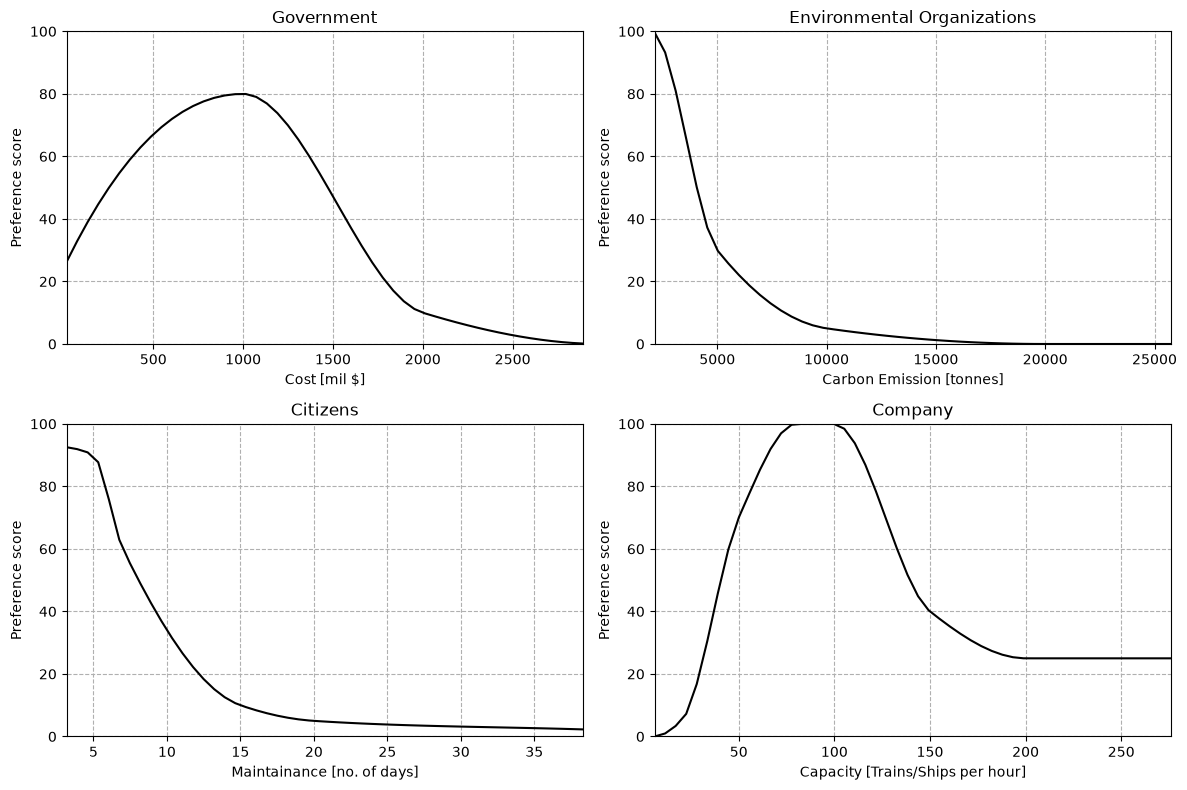

In [120]:
# Define preferences
prefs_before = [[[50 , 1000, 2000, 3000, 3200 ],             [30, 80,10, 0, 0]],          # preference cost
                [[0,  2000, 5000, 10000, 20000, 21000],                      [100, 100, 30, 5, 0, 0]],          # carbon emission
                [[0, 1, 5, 7, 15, 20, 40, 50, 80],    [100, 95, 90 , 60, 10, 5, 2, 0, 0]],   # days of maintennce
                [[6, 20, 50, 80,90, 100, 150, 200, 250, 280],                      [0, 5, 70,100, 100, 100,  40, 25, 25, 25]]] 
    # preference capacity


pref_after = [
    [[150000, 2000000, 4250000], [100, 80, 0]],
    [[8, 120, 350], [0, 60, 100]],
    [[0, 80000, 150000, 375000], [0, 100, 50, 0]],
    [[2, 9.5], [100, 0]]
]

prefs = prefs_before  # set to which preferences to use


# Preference curve values for plotting
# Generate objective value ranges 
obj_vals_list = []
for _, name, _, _ in objectives:
    obj_vals = np.linspace(*objective_minmax[name])
    obj_vals_list.append(obj_vals)

# Generate preference values using interpolation
pref_vals_list = []
for pref, obj_vals in zip(prefs, obj_vals_list):
    pref_vals = pchip_interpolate(pref[0], pref[1], obj_vals)
    pref_vals_list.append(pref_vals)

# Plotting the initial preference curves 
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, (obj_vals, p_vals), (_, name, unit, stakeholder) in zip(axes.flat, zip(obj_vals_list, pref_vals_list), objectives):
    ax.plot(obj_vals, p_vals, color='black')
    ax.set_xlim(min(obj_vals), max(obj_vals))
    ax.set_ylim(0, 100)
    ax.set_title(stakeholder)
    ax.set_xlabel(f'{name} [{unit}]')
    ax.set_ylabel('Preference score')
    ax.grid(linestyle='--')

fig.tight_layout()
plt.show()


# Defines preference functions (accepts x1 through x5)
def pref_func_1(x1, x2, x3, x4, x5):
    cost = objective_function_1(x1, x2, x3, x4, x5)
    return pchip_interpolate(prefs[0][0], prefs[0][1], cost)

def pref_func_2(x1, x2, x3, x4, x5):
    ride = objective_function_2(x1, x2, x3, x4, x5)
    return pchip_interpolate(prefs[1][0], prefs[1][1], ride)

def pref_func_3(x1, x2, x3, x4, x5):
    sed = objective_function_3(x1, x2, x3, x4, x5)
    return pchip_interpolate(prefs[2][0], prefs[2][1], sed)

def pref_func_4(x1, x2, x3, x4, x5):
    safe = objective_function_4(x1, x2, x3, x4, x5)
    return pchip_interpolate(prefs[3][0], prefs[3][1], safe)


pref_funcs = [pref_func_1, pref_func_2, pref_func_3, pref_func_4]


def objective(variables):
    """
    Objective function fed to GA. Unpacks 5 variables.
    """
    x1 = variables[:, 0]
    x2 = variables[:, 1]
    x3 = variables[:, 2]
    x4 = variables[:, 3]
    x5 = variables[:, 4]  # Fixed: extracted x5 from population array

    # calculate the preference scores
    p_1 = pref_func_1(x1, x2, x3, x4, x5)
    p_2 = pref_func_2(x1, x2, x3, x4, x5)
    p_3 = pref_func_3(x1, x2, x3, x4, x5)
    p_4 = pref_func_4(x1, x2, x3, x4, x5)
    
    return weights, [p_1, p_2, p_3, p_4]



## Optimisation

Now that everything is in place, we can run the optimisation. For more details on the available configuration options, see the docstring of `GeneticAlgorithm` (accessible via `help()`). Note that a genetic algorithm relies on randomness, so it is expected that results will differ slightly between separate executions.

The optimisation can be run using three aggregation methods: `'minmax'`, `'a-fine'`, and optionally `'tetra'`. These methods differ in how the individual preference scores are combined into a group preference during the optimisation process; see `aggregations.md` for more information on how each method works and when to use it. These methods determine, mathematically, what is considered the "best" group preference. However, what is considered "best" is not purely a mathematical question, it also involves a qualitative judgement about which outcome is most appropriate for the problem at hand.

After computing the optimal results, the solutions are plotted on top of their corresponding preference curves.


Run GA with minmax
The type of aggregation is set to minmax
Generation   Best score   Mean             Max stall    Diversity    Number of non-feasible results
0            14.9029      95500014.6476    0            0.003        182         
1            13.6855      12500015.9002    0            0.086        24          
2            13.4078      8000014.7619     0            0.117        15          
3            13.4023      23000013.3527    0            0.162        45          
4            13.3869      9000013.7754     0            0.18         17          
5            13.3869      5000013.7328     1            0.187        9           
6            13.3869      8500013.357      2            0.19         16          
7            13.3869      6000013.4064     3            0.188        11          
8            13.3869      5500013.4251     4            0.188        10          
9            13.3869      4000013.5808     5            0.189        7           
10           13.386

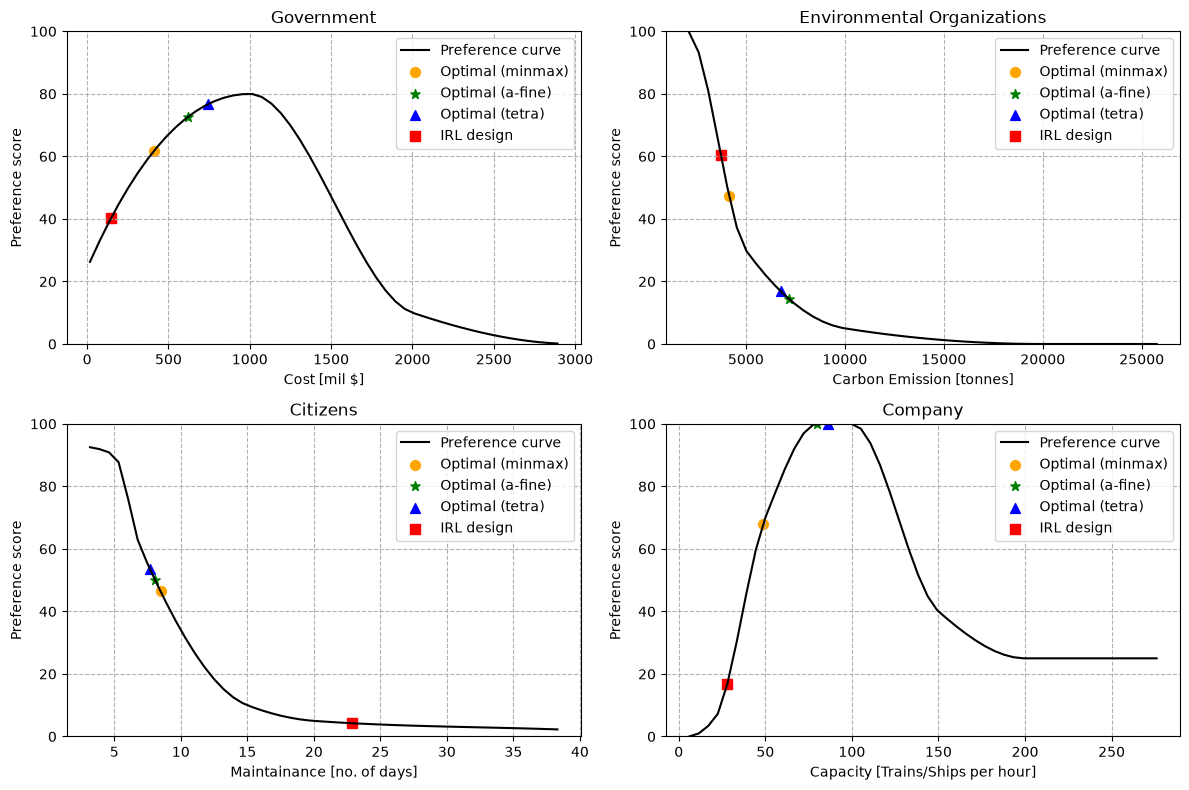

In [121]:
# Optimization run
paradigm = ['minmax', 'a-fine', 'tetra']
markers  = ['o', '*', '^']                 # Fixed: replaced invalid '-' with '^'
colours  = ['orange', 'green', 'blue']

# 2x2 grid fits 4 objectives exactly
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Plot underlying preference curves
for ax, o_vals, p_vals, (_, name, unit, stakeholder) in zip(axes.flat, obj_vals_list, pref_vals_list, objectives): 
    ax.plot(o_vals, p_vals, color='black', label='Preference curve')
    #ax.set_xlim(min(o_vals), max(o_vals))
    ax.set_ylim(0, 100)
    ax.set_title(stakeholder)
    ax.set_xlabel(f'{name} [{unit}]')
    ax.set_ylabel('Preference score')
    ax.grid(linestyle='--')

for i in range(len(paradigm)):
    options = {
        'n_bits': 8,
        'n_iter': 400,
        'n_pop': 500,
        'r_cross': 0.8,
        'max_stall': 16,
        'aggregation': paradigm[i],  
        'var_type': 'real'
    }

    print(f'\nRun GA with {paradigm[i]}')
    ga = GeneticAlgorithm(objective=objective, constraints=cons, bounds=bounds, options=options)
    _, optimal_design_var, _ = ga.run()

    print(f'Optimal design variable values using {paradigm[i]}:') 
    for opt_var, (xi, name, unit) in zip(optimal_design_var, design_variables):
        print(f'  {xi} : {name:<25} = {opt_var:>10.2f} {unit}') 

    print(f'Optimal objective results and stakeholder preference using {paradigm[i]}:')
    for j, (ax, (obj_func, name, unit, stakeholder)) in enumerate(zip(axes.flat, objectives)):
        obj_value = obj_func(*optimal_design_var)
        pref_score = pref_funcs[j](*optimal_design_var)
    
        print(f'  {name:<20} = {obj_value:>15,.2f} {unit:<10} -> {stakeholder:<20} pref: {pref_score:>6.2f}')
        ax.scatter(obj_value, pref_score, color=colours[i], marker=markers[i], s=50,
                   label=f'Optimal ({paradigm[i]})')

# Plot IRL design point if requested
if plot_irl:   
    irl_obj_values = [obj_func(*X_irl) for obj_func, _, _, _ in objectives]
    irl_pref_scores = [pref_funcs[j](*X_irl) for j in range(len(objectives))]
    for j, ax in enumerate(axes.flat[:4]):
        ax.scatter(irl_obj_values[j], irl_pref_scores[j], color='red', marker='s', s=50, label='IRL design')

for ax in axes.flat:
    ax.legend(fontsize=10)

fig.tight_layout()
plt.show()